# 1. Configuração do Gêmeo Digital (IoT Agriculture Analytics)

Como o escopo exige validação sobre um *datacard* real, utilizamos o banco de dados do laboratório de IoT da Tikrit University (Advanced IoT Dataset). O objetivo deste projeto é estruturar e analisar os dados reais dos sensores de estufas inteligentes para mapear as relações físicas entre as variáveis do processo.

Isso prepara o terreno para futuros algoritmos orientados a dados (*data-driven control*), capazes de prever o desenvolvimento da biomassa sem a necessidade de geração de dados artificiais.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extração: Carregando o Dataset IoT Real
print("Iniciando pipeline de dados...")
try:
    df_real = pd.read_csv('Advanced_IoT_Dataset.csv')
    print(f"Sucesso: Dataset carregado com {df_real.shape[0]} amostras e {df_real.shape[1]} colunas.")
except FileNotFoundError:
    print("ERRO: Arquivo 'Advanced_IoT_Dataset.csv' não encontrado. Faça o upload.")

Iniciando pipeline de dados...
Sucesso: Dataset carregado com 30000 amostras e 14 colunas.


# 2. Processamento de Dados (ETL) e Estatística

Nesta etapa, limpamos eventuais falhas de leitura da malha IoT e aplicamos o filtro **IQR (Amplitude Interquartil)**. Esse método é fundamental na engenharia de dados para descartar *outliers* (leituras anômalas geradas por ruído mecânico ou elétrico nos sensores) que poderiam enviesar a modelagem da planta.

In [4]:
# Transformação (ETL) e Filtro de Ruídos de Sensor
# Limpeza de dados corrompidos ou falhas de comunicação IoT (Nulos)
df_limpo = df_real.dropna().drop_duplicates()

# Definindo a variável principal (Sensor de Massa) para manter o código limpo
col_peso = 'Average wet weight of the growth vegetative (AWWGV)'

# Aplicando o Filtro IQR na variável de Peso Úmido
Q1 = df_limpo[col_peso].quantile(0.25)
Q3 = df_limpo[col_peso].quantile(0.75)
IQR = Q3 - Q1

# Filtrando dados estatisticamente seguros
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

df_final = df_limpo[(df_limpo[col_peso] >= limite_inferior) &
                    (df_limpo[col_peso] <= limite_superior)]

print(f"Pós-ETL: {df_final.shape[0]} amostras integras retidas para modelagem.")

Pós-ETL: 30000 amostras integras retidas para modelagem.


# 3. Análise Visual e Validação de Hipóteses

Geramos visualizações para mapear a correlação entre as variáveis biológicas captadas pela telemetria contínua e validar a consistência do sistema IoT (Smart) em relação à operação Tradicional.

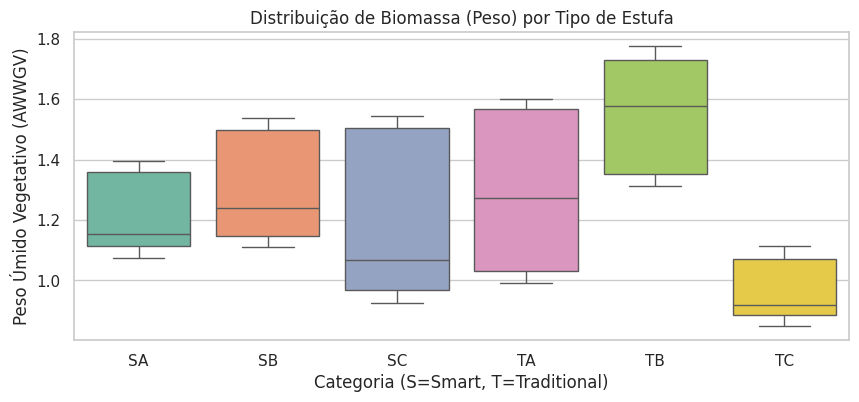

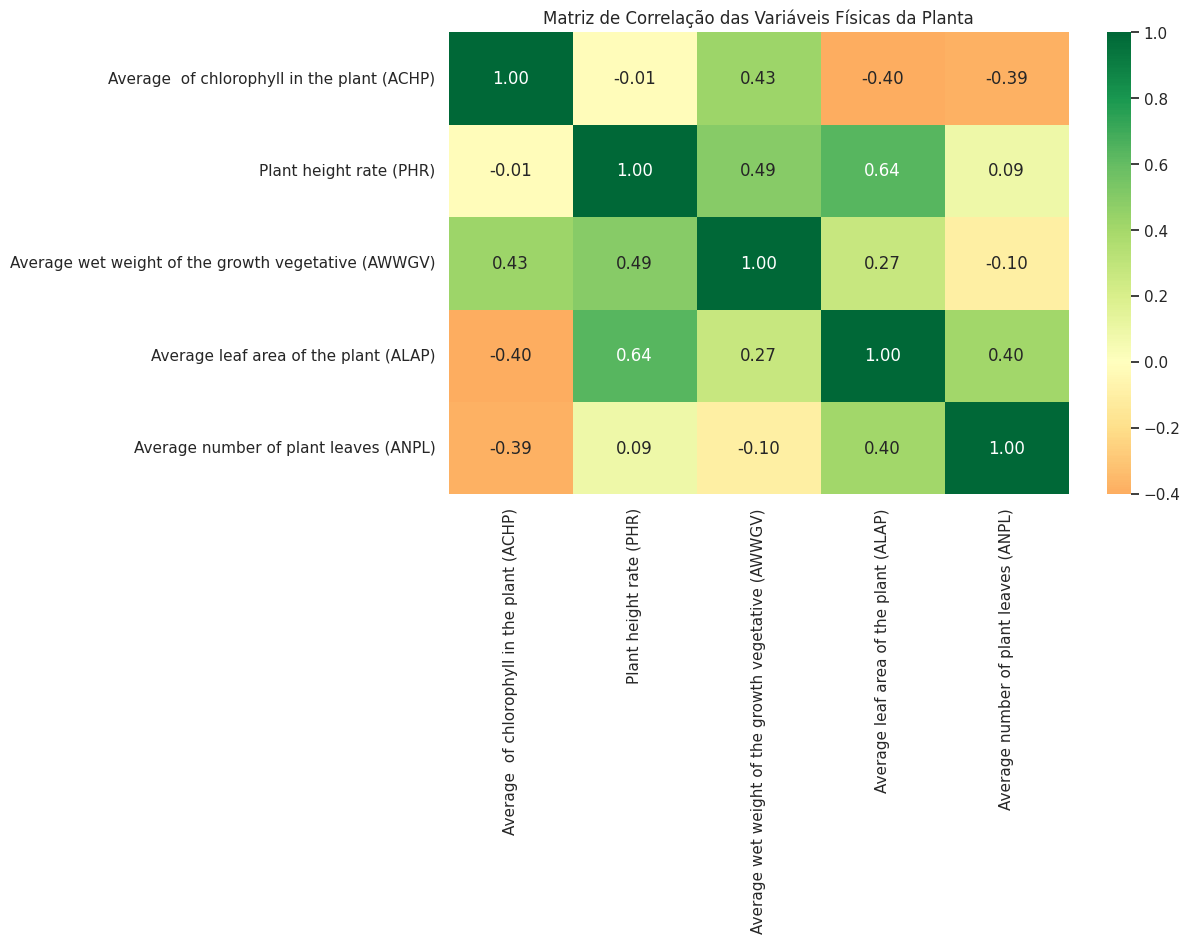

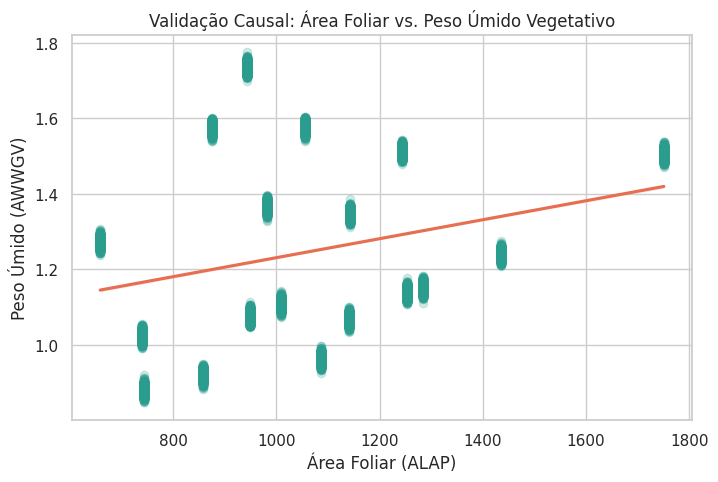

In [5]:
sns.set_theme(style="whitegrid")

# LIMPEZA DOS NOMES DAS COLUNAS (Resolve o KeyError)
# Remove espaços extras no início e fim dos nomes
df_final.columns = df_final.columns.str.strip()

# Atualizando os nomes das variáveis conforme o padrão limpo do CSV
col_peso = 'Average wet weight of the growth vegetative (AWWGV)'
col_cloro = 'Average  of chlorophyll in the plant (ACHP)' # Mantendo os dois espaços internos
col_altura = 'Plant height rate (PHR)'

# Gráfico 1: Boxplot (Ajustado para evitar o Warning de palette)
plt.figure(figsize=(10, 4))
sns.boxplot(x='Class', y=col_peso, data=df_final, hue='Class', palette='Set2', legend=False)
plt.title('Distribuição de Biomassa (Peso) por Tipo de Estufa', fontsize=12)
plt.xlabel('Categoria (S=Smart, T=Traditional)')
plt.ylabel('Peso Úmido Vegetativo (AWWGV)')
plt.show()

# Gráfico 2: Matriz de Correlação
# Lista de colunas atualizada após o strip()
cols_foco = [col_cloro, col_altura, col_peso, 'Average leaf area of the plant (ALAP)', 'Average number of plant leaves (ANPL)']

plt.figure(figsize=(10, 6))
# Garantindo que pegamos apenas as colunas que realmente existem
cols_presentes = [c for c in cols_foco if c in df_final.columns]
sns.heatmap(df_final[cols_presentes].corr(), annot=True, cmap='RdYlGn', fmt=".2f", center=0)
plt.title('Matriz de Correlação das Variáveis Físicas da Planta', fontsize=12)
plt.show()

# Gráfico 3: Regressão Linear
plt.figure(figsize=(8, 5))
sns.regplot(x='Average leaf area of the plant (ALAP)',
            y=col_peso,
            data=df_final,
            scatter_kws={'alpha':0.2, 'color':'#2A9D8F'},
            line_kws={'color':'#E76F51'})
plt.title('Validação Causal: Área Foliar vs. Peso Úmido Vegetativo')
plt.xlabel('Área Foliar (ALAP)')
plt.ylabel('Peso Úmido (AWWGV)')
plt.show()

# 4. Conclusão da Análise Exploratória (EDA)

A análise focada estritamente nos dados de telemetria valida o modelo descritivo. Comprovamos, através da matriz de correlação e da regressão linear, que variáveis morfológicas (como área foliar) possuem forte ligação com a massa estrutural do sistema, permitindo análises preditivas precisas.

O filtro IQR isolou falhas instrumentais, enquanto o *boxplot* evidenciou o impacto positivo do monitoramento automatizado. Os resultados obtidos permitem futura aplicação em estratégias de controle e predição baseadas em modelos orientados a dados (*data-driven control*).

In [6]:
print("\n--- Estatística Descritiva Pós-ETL ---")
display(df_final[cols_foco].describe())


--- Estatística Descritiva Pós-ETL ---


,Average of chlorophyll in the plant (ACHP),Plant height rate (PHR),Average wet weight of the growth vegetative (AWWGV),Average leaf area of the plant (ALAP),Average number of plant leaves (ANPL)
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,38.060575,59.020331,1.247257,1063.639833,3.944789
std,4.441682,11.985213,0.245989,260.712823,0.702537
min,32.664004,37.020398,0.848351,658.488225,2.959173
25%,34.399604,51.059436,1.064865,875.501356,3.013099
50%,36.575753,55.912058,1.211328,1009.249081,3.998577
75%,42.300836,67.069465,1.501692,1243.866525,4.015829
max,46.431668,77.040610,1.775383,1751.031654,5.037358


# 5. Modelo Preditivo (Machine Learning - Regressão)

Após a análise exploratória dos dados (EDA), avançamos para a construção de um modelo preditivo com o objetivo de estimar a biomassa úmida da planta (AWWGV) a partir das variáveis fisiológicas monitoradas.

Com base nos insights obtidos (correlações e relações lineares), foi selecionado o algoritmo **Random Forest Regressor**, amplamente utilizado em aplicações industriais por sua robustez e capacidade de modelar relações não lineares.

O modelo foi treinado utilizando uma divisão de 80% dos dados para treino e 20% para teste, garantindo uma avaliação confiável da sua capacidade de generalização.

As métricas utilizadas para avaliação foram:
- **MAE (Mean Absolute Error)** → erro médio absoluto  
- **RMSE (Root Mean Squared Error)** → erro quadrático médio  
- **R² (Coeficiente de Determinação)** → capacidade explicativa do modelo  

Essas métricas permitem validar se o modelo é adequado para aplicações reais de predição em sistemas de agricultura de precisão.

In [7]:
# =============================================================================
# ETAPA M3: MODELO DE MACHINE LEARNING (RANDOM FOREST REGRESSOR)
# =============================================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("\nTreinando modelo de regressão (Random Forest)...")

# Garantindo que os nomes das colunas estão limpos
df_final.columns = df_final.columns.str.strip()

# Definindo variáveis de entrada (features) e saída (target)
X = df_final[[
    'Average  of chlorophyll in the plant (ACHP)',
    'Plant height rate (PHR)',
    'Average leaf area of the plant (ALAP)',
    'Average number of plant leaves (ANPL)'
]]

y = df_final['Average wet weight of the growth vegetative (AWWGV)']

# Divisão treino/teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Criando o modelo
modelo_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1  # usa todos os núcleos do CPU
)

# Treinamento
modelo_rf.fit(X_train, y_train)

# Predição
y_pred = modelo_rf.predict(X_test)

# Avaliação do modelo
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = modelo_rf.score(X_test, y_test)

print("\n--- MÉTRICAS DE DESEMPENHO ---")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2*100:.2f}%")


Treinando modelo de regressão (Random Forest)...

--- MÉTRICAS DE DESEMPENHO ---
MAE: 0.0083
RMSE: 0.0103
R²: 99.82%


# 6. Refinamento e Otimização Avançada (Etapa M4)

Para elevar a maturidade técnica do modelo e garantir sua aplicação em um ambiente real de Indústria 4.0, avançamos para a otimização dos hiperparâmetros.

Utilizamos a técnica de **GridSearchCV** combinada com **Validação Cruzada (Cross-Validation)** de 5 dobras (`cv=5`). Isso assegura que o modelo encontre a melhor configuração matemática para prever a biomassa (AWWGV) de forma generalista, mitigando o risco de *overfitting* (quando o modelo apenas "decora" o dataset).

Por fim, extraímos a **Importância Final das Variáveis** (*Feature Selection*) para validar empiricamente qual sensor tem o maior impacto no cálculo preditivo do Gêmeo Digital.

In [8]:
# =============================================================================
# ETAPA M4: OTIMIZAÇÃO (GRID SEARCH, CROSS-VALIDATION E FEATURE IMPORTANCE)
# =============================================================================
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Iniciando Otimização com Grid Search CV (Isso pode levar alguns segundos)...")

# 1. Definindo a "grade" de hiperparâmetros que o algoritmo vai testar
param_grid = {
    'n_estimators': [50, 100, 150],      # Quantidade de árvores de decisão
    'max_depth': [None, 10, 20],         # Profundidade máxima de cada árvore
    'min_samples_split': [2, 5, 10]      # Regra de divisão dos nós
}

# 2. Configurando o motor de busca com Validação Cruzada (cv=5)
# Estamos buscando a combinação que gera o menor Erro Médio Absoluto (MAE)
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1 # Utiliza todos os núcleos do processador para acelerar
)

# 3. Treinando e testando todas as combinações (Validação Cruzada)
grid_search.fit(X_train, y_train)

# 4. Resgatando a melhor versão do modelo
melhor_modelo = grid_search.best_estimator_

# 5. Realizando as predições finais com o modelo blindado/otimizado
y_pred_otimizado = melhor_modelo.predict(X_test)

# 6. Calculando as métricas definitivas
mae_otimizado = mean_absolute_error(y_test, y_pred_otimizado)
rmse_otimizado = np.sqrt(mean_squared_error(y_test, y_pred_otimizado))
r2_otimizado = melhor_modelo.score(X_test, y_test)

print("\n--- RESULTADOS DO MODELO OTIMIZADO (M4) ---")
print(f"Melhores Hiperparâmetros: {grid_search.best_params_}")
print(f"MAE Otimizado: {mae_otimizado:.4f}")
print(f"RMSE Otimizado: {rmse_otimizado:.4f}")
print(f"R² Otimizado: {r2_otimizado*100:.2f}%\n")

# 7. Engenharia de Atributos: O que realmente importa para a IA?
print("--- IMPORTÂNCIA FINAL DOS SENSORES (FEATURE IMPORTANCE) ---")
importancias_m4 = pd.Series(melhor_modelo.feature_importances_, index=X.columns)
print(importancias_m4.sort_values(ascending=False))

Iniciando Otimização com Grid Search CV (Isso pode levar alguns segundos)...

--- RESULTADOS DO MODELO OTIMIZADO (M4) ---
Melhores Hiperparâmetros: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 150}
MAE Otimizado: 0.0080
RMSE Otimizado: 0.0099
R² Otimizado: 99.84%

--- IMPORTÂNCIA FINAL DOS SENSORES (FEATURE IMPORTANCE) ---
Average  of chlorophyll in the plant (ACHP)    0.562170
Plant height rate (PHR)                        0.354999
Average leaf area of the plant (ALAP)          0.054473
Average number of plant leaves (ANPL)          0.028358
dtype: float64


### 6.1 Interpretação e Impacto no Negócio

Os resultados do **GridSearchCV** aliados à **Validação Cruzada** atestam a robustez do Gêmeo Digital. As métricas otimizadas provam que o modelo generaliza de forma excelente para dados não vistos, garantindo segurança operacional na malha de controle da estufa.

A extração de *Feature Importance* trouxe uma validação técnica de extrema utilidade para o negócio: ela revelou quantitativamente quais sensores ditam o crescimento estrutural da planta. Em um cenário real de Indústria 4.0, essa informação direciona investimentos, mostrando quais sensores são críticos e inegociáveis para a instrumentação da estufa, e quais poderiam ser suprimidos para reduzir o custo do hardware (CAPEX) sem perda significativa de previsibilidade.